# Libraries

In [88]:
%load_ext autoreload
%autoreload 2
# Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap
import captum
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Bundle net repo
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
# xai methods .py documents
from xai_methods import BehaviorWrapper, get_integrated_gradients, get_shap_values
from xai_visualizations import plot_global_importance, plot_transition_heatmap, plot_full_temporal_dashboard , plot_shap_beeswarm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Preparing data

In [86]:
worm_num = 2
algorithm = 'BunDLe-Net'
data_path = "C:/Users/olgas/OneDrive/Documents/GitHub/Bundle-Net-Project/dataset/c_elegans/NoStim_Data.mat"
data = Database(data_path=data_path, dataset_no=worm_num)
x = data.neuron_traces.T
b = data.behaviour

In [27]:
label_encoder = LabelEncoder()
b = label_encoder.fit_transform(b)
print(x.shape, b.shape)
x_, b_ = prep_data(x, b, win=1)
print(x_.shape, b_.shape)

(3059, 131) (3059,)
(3058, 2, 1, 131) (3058,)


In [ ]:
# Preparing tensor with 300 for behaviour 2 
b_new = b[:len(x_)]
behaviour = 2
time_index = np.where(b_new == behaviour)[0]

x_raw_2 = x_[time_index, 0, :, :]
x_tensor_2 = torch.tensor(x_raw_2, dtype=torch.float32, requires_grad=True)

In [ ]:
table = x_tensor_2.detach().cpu().numpy().squeeze()
df = pd.DataFrame(table, columns=data.neuron_names)
print(f"Data Size: {df.shape[0]} klatek (wierszy) na {df.shape[1]} neuronów (kolumn)")
display(df)

# Model traning

In [28]:
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names), input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=500
)

Loss [Markov, Behaviour, Total]: [0.0082 0.005  0.0133]: 100%|██████████| 500/500 [00:49<00:00, 10.02it/s]


# XAI attribuition score calculating

In [ ]:
# Calculating the IG 
ig_attr = get_integrated_gradients(model, x_tensor_2, target_class=behaviour)
# Calculating teh Shap
shap_attr = get_shap_values(model, x_tensor_2, target_class=behaviour)

# GLOBAL IMPORTANCE PANEL

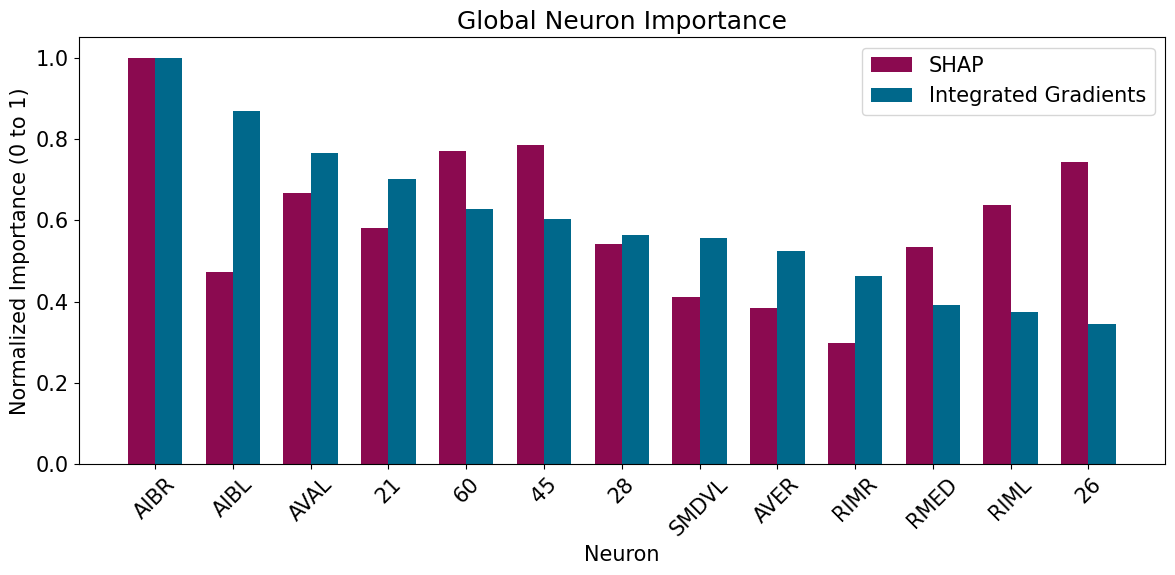

In [97]:
plt.rcParams.update({'font.size': 15})
plot_global_importance(attributions_shap = shap_attr, attributions_ig = ig_attr, neuron_names=data.neuron_names, top_n=10, title="Global Neuron Importance")


c:\Users\olgas\OneDrive\Documents\GitHub\Bundle-Net-Project\code\xai_visualizations.py:163: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.


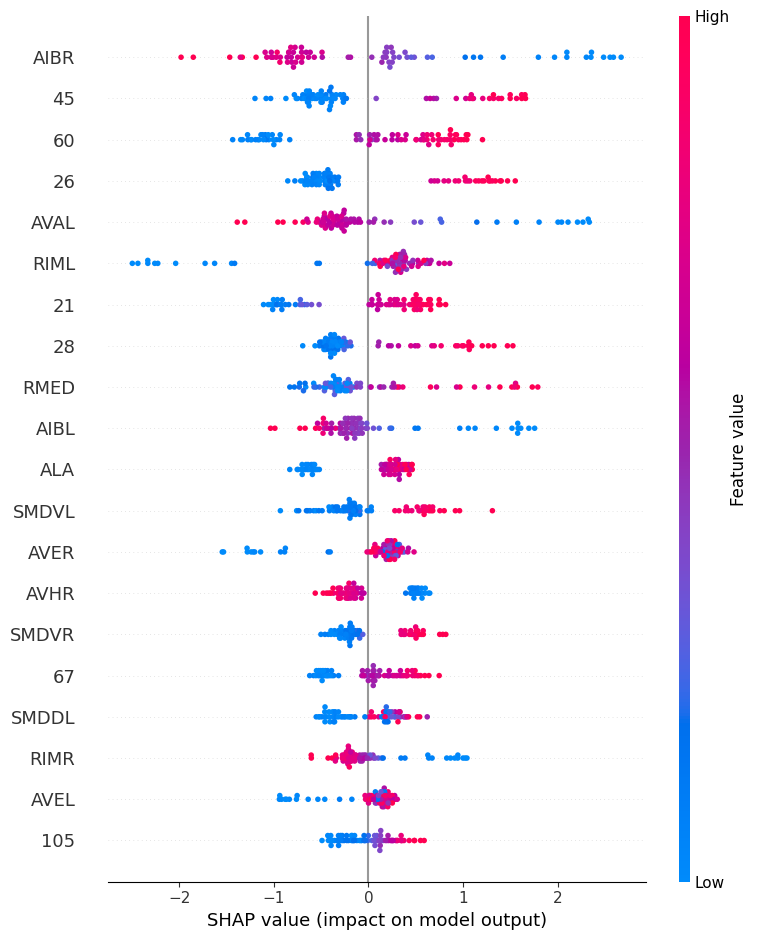

In [91]:
plot_shap_beeswarm(shap_attr, x_tensor_2, data.neuron_names) 

In [ ]:
ig_matrix_2d = ig_attr.squeeze() 

plot_full_temporal_dashboard(
    x_raw=x, # Zwykła tablica z danymi, nie tensor
    behaviors=b, 
    behavior_names=data.behaviour_names,
    ig_matrix=ig_matrix_2d,
    neuron_names=data.neuron_names,
    top_n=10
)